# 04 · Policy and semantic diagnostics

**Question:** Where does the representation succeed, where does it fail, and how much does it depend on its supplied examples?

This notebook examines the expanded development study. It keeps ranking, probability quality and support dependence separate. No result here consumes the confirmation reserve.

In [1]:
import os
from pathlib import Path
import pandas as pd
from IPython.display import display
from jigsaw_rules.review import public_evidence
from jigsaw_rules.runtime import environment

root = Path(os.environ.get("JIGSAW_ROOT", Path.cwd())).resolve()
if root.name == "notebooks":
    root = root.parent
baseline = public_evidence(root, "baseline")
semantic = public_evidence(root, "semantic")
assert baseline["training_sha256"] == semantic["training_sha256"]
print("Historical references: 2,029 rows, two policies; expanded research is a separate cohort.")
print("Aggregate checksums verified. This notebook performs no model fitting.")
protocols = {"seen_rule": "Familiar rules", "heldout_rule": "Held-out rule"}

def metric_table(records, heldout=False):
    return pd.DataFrame([{"Representation": r["model"], "Validation": protocols[r["protocol"]],
        "Rule macro AUC": r["metrics"]["rule_macro_auc"],
        "Log loss": r["metrics"]["log_loss"], "Brier": r["metrics"]["brier"],
        "Average precision": r["metrics"]["average_precision"]}
        for r in records if not heldout or r["protocol"] == "heldout_rule"]).round(4)


Historical references: 2,029 rows, two policies; expanded research is a separate cohort.
Aggregate checksums verified. This notebook performs no model fitting.


In [2]:
import sys
sys.path.insert(0, str(root / "scripts"))
from build_research_report import display_figure
from build_release_report import display_boundary
from jigsaw_rules.features import feature_evidence
from jigsaw_rules.research import research_evidence
from jigsaw_rules.diagnostics import diagnostic_evidence
from jigsaw_rules.pairs import pairs_evidence
from jigsaw_rules.robustness import robustness_evidence
from jigsaw_rules.gate import feature_gate
from jigsaw_rules.instructions import instruction_evidence
from jigsaw_rules.released import released_evidence
from jigsaw_rules.expanded import expanded_evidence
from jigsaw_rules.retrieval import retrieval_evidence
from jigsaw_rules.resolution import resolution_evidence
from jigsaw_rules.formatting import formatting_evidence
from jigsaw_rules.feature_decision import decision_evidence
from build_expanded_report import display_figure as display_expanded
from build_formatting_report import display_figure as display_formatting

expanded = expanded_evidence(root)
retrieval = retrieval_evidence(root)
resolution = resolution_evidence(root)
formatting = formatting_evidence(root)
decision = decision_evidence(root)
assert expanded is not None and retrieval is not None and resolution is not None
assert formatting is not None and decision is not None
controls = feature_evidence(root)
research = research_evidence(root)
sensitivity = diagnostic_evidence(root)
pairs = pairs_evidence(root)
robustness = robustness_evidence(root)
assert all(item is not None for item in (controls, research, sensitivity, pairs, robustness))
gate = feature_gate(root)
instructions = instruction_evidence(root)
released = released_evidence(root)
assert released is not None
print("Verified expanded study:", expanded["metadata"]["run_id"])


Verified expanded study: a57bb74350fcbcd66592


## Policy-level performance can contradict the average
The held-out-policy models train on the other three policies. Fixed semantic scores do not fit labels; their identical predictions across validation protocols are not independent replications. A policy-level failure remains meaningful even if the overall mean improves.

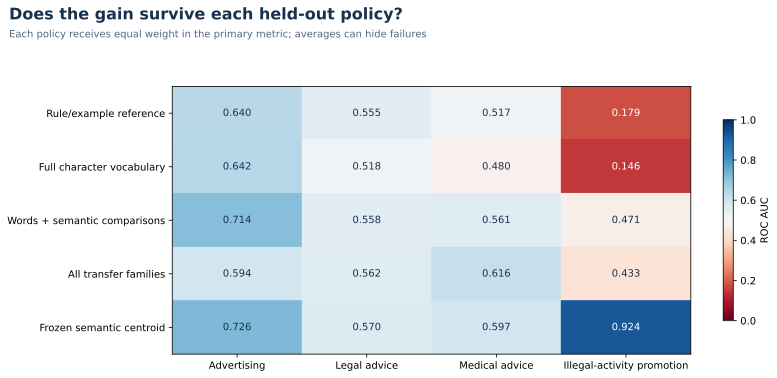

Policy,No Advertising,No legal advice,No medical advice,No promotion of illegal activity
Representation,,,,
all_transfer,0.5936,0.5623,0.6165,0.4334
character_full,0.6422,0.5179,0.4798,0.1458
qwen_centroid,0.7255,0.5702,0.5969,0.9241
rule_examples,0.6400,0.5545,0.5173,0.1793
word_semantic_scalar,0.7138,0.5581,0.5611,0.4713


In [3]:
display_expanded(root, "policies")
selected = ["rule_examples", "character_full", "word_semantic_scalar", "all_transfer", "qwen_centroid"]
records = [r for r in expanded["results"] if r["protocol"] == "heldout_rule" and r["model"] in selected]
per_rule = pd.DataFrame([{"Representation": r["model"], "Policy": rule.split(":")[0], "ROC AUC": auc} for r in records for rule, auc in r["metrics"]["per_rule_auc"].items()])
display(per_rule.pivot(index="Representation", columns="Policy", values="ROC AUC").round(4))

## Ranking is not probability calibration
Log loss and Brier assess probability quality; lower is better. Calibration error uses ten equal-width bins. Precision/recall/F1 use the fixed diagnostic threshold 0.5. There is no fitted calibrator or selected moderation threshold. Frozen centroid temperatures define scoring scales, not validated probability estimates.

In [4]:
display(metric_table(records))
diagnostics = pd.DataFrame([{"Representation": r["model"], "Pooled AUC": r["metrics"]["pooled_auc"], "Calibration error": r["metrics"]["ece_10_equal_width_bins"], "Precision@0.5": r["metrics"]["precision_at_0_5"], "Recall@0.5": r["metrics"]["recall_at_0_5"], "F1@0.5": r["metrics"]["f1_at_0_5"]} for r in records])
display(diagnostics.round(4))

,Representation,Validation,Rule macro AUC,Log loss,Brier,Average precision
0,all_transfer,Held-out rule,0.5515,1.4700,0.4503,0.5057
1,character_full,Held-out rule,0.4464,0.9169,0.3345,0.5221
2,qwen_centroid,Held-out rule,0.7042,0.6237,0.2177,0.7559
3,rule_examples,Held-out rule,0.4728,0.8126,0.2992,0.5294
4,word_semantic_scalar,Held-out rule,0.5761,0.8156,0.2969,0.5727


,Representation,Pooled AUC,Calibration error,Precision@0.5,Recall@0.5,F1@0.5
0,all_transfer,0.4188,0.4400,0.4391,0.3469,0.3876
1,character_full,0.4798,0.2786,0.5065,0.4313,0.4659
2,qwen_centroid,0.7001,0.0322,0.6759,0.6761,0.6760
3,rule_examples,0.4810,0.2111,0.5303,0.5002,0.5148
4,word_semantic_scalar,0.5552,0.2272,0.5667,0.4115,0.4768


## How much does the supplied support set matter?
A centroid comparison asks whether a comment is closer to positive than negative examples under a rule-conditioned frozen embedding. One-example-per-class scoring averages every positive/negative choice. Shuffling complete support contexts within the same policy tests dependence on the particular supplied context. Exact self-support exclusion tests whether copied examples explain performance. These are fixed diagnostics, not new tuned models.

In [5]:
stress = expanded["audit"]["support_stress"]
centroid = next(r["metrics"] for r in records if r["model"] == "qwen_centroid")
comparison = {"Original supplied context": centroid, **{name: value for name, value in stress.items() if isinstance(value, dict)}}
display(pd.DataFrame([{ "Condition": name, "Policy-macro AUC": value["rule_macro_auc"], "Log loss": value["log_loss"], "Brier": value["brier"]} for name, value in comparison.items()]).round(4))
print("Self-support rows excluded:", stress["self_match_rows"])

,Condition,Policy-macro AUC,Log loss,Brier
0,Original supplied context,0.7042,0.6237,0.2177
1,one_example_per_class,0.6918,0.6620,0.2349
2,within_policy_context_shuffle,0.7062,0.6228,0.2172
3,exclude_self_matches,0.7034,0.6246,0.2181


Self-support rows excluded: 18


## Calibration is a separate generalization question
Three inner pipelines per familiar outer split produce calibration-only OOF scores. Outer validation labels fit neither the feature pipeline nor its calibrator. For the label-free centroid, the calibrator uses only each purged outer training partition. Each protocol still evaluates all 11,135 development rows exactly once.

The curves below are descriptive diagnostics. The decision requires practical log-loss improvement, a positive paired interval, Brier tolerance, macro/per-policy AUC tolerance and per-policy log-loss tolerance. Familiar calibration passes; transfer calibration fails. Different policies can have different probability errors even when a monotone transform preserves their ranking.

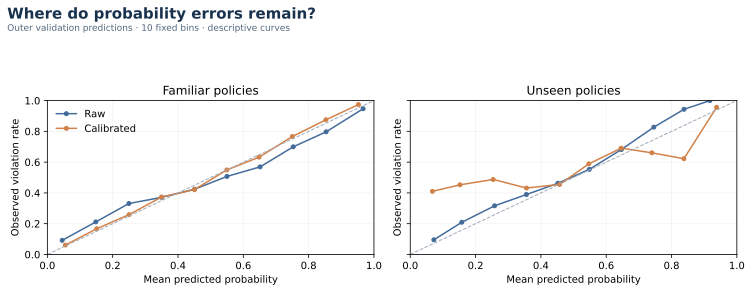

,seen_rule,heldout_rule
practical_log_loss_gain,True,False
paired_loss_interval,True,False
brier_tolerance,True,False
macro_auc_tolerance,True,True
policy_auc_tolerance,True,True
policy_log_loss_tolerance,True,False


In [6]:
from jigsaw_rules.model_validation import validation_evidence
from build_model_report import display_figure as display_model
validated = validation_evidence(root)
assert validated is not None
display_model(root, "reliability")
display(pd.DataFrame({name: decision["checks"] for name, decision in validated["calibration"]["decisions"].items()}))

## Compute is part of the representation decision
The expanded study reuses 1,875 verified original inputs and encodes 10,098 missing inputs, for 11,973 unique rule/comment or rule/example queries. Four CPU workers use the pinned model and immutable input contract. Completed shards and folds are checksummed and checkpointed to S3; interrupted active stages restart while completed work is preserved.

All 190 cache shards are verified. Their statistics record 11,977 encoded occurrences (11,973 unique inputs), two truncations, a maximum original length of 337 tokens and peak per-worker RSS of 3.85 GiB. The six-resolution comparison keeps 1,024 dimensions as the strongest reference; shorter outputs do not accelerate the transformer itself.

Embedding coordinates and compact comparisons share the same encoder cost, but their fitted feature dimensions differ. The final product still needs measured end-to-end latency, memory, offline parity and a support-availability policy after a candidate earns promotion.

In [7]:
display(pd.Series(expanded["audit"]["embedding_cache"], name="Verified expanded cache"))
print("Research run:", expanded["metadata"]["run_id"])
print("Final training justified:", gate["final_training_authorized_by_evidence"])

cache                                                   bc433d2324dd22713bba
contract_sha256            bc433d2324dd22713bba38c4f3e60e3a4093e1253d1e57...
shards_sha256              068aafab1ec970cc04558b9b22d1c65b30b0414ef6440f...
shards_verified                                                          190
requested_inputs                                                       55675
unique_requested_inputs                                                11973
newly_encoded_inputs                                                       0
Name: Verified expanded cache, dtype: object

Research run: a57bb74350fcbcd66592
Final training justified: True


## Do intent features resolve the weak policies?
Semantic-plus-intent slightly improves legal and medical ranking, but damages advertising and probability quality. The fixed average retains part of that tradeoff; it fails the predeclared acceptance rule. The qualitative audit contains 48 deliberately balanced examples, not a prevalence sample. Context and speech-act ambiguity are useful error mechanisms, not proof that the source labels are wrong.

The new job encoded 2,217 unique plain supports and 21,214 unique NLI pairs, with zero and four truncated inputs respectively. Original comment embeddings were reused. Compatible historical NLI predictions were not present in this job's restored inputs; the new 332-shard NLI cache is now checkpointed and reusable. Worker computation took 644.5 seconds on one bounded CPU instance; summed encoder time across parallel workers is not wall time.

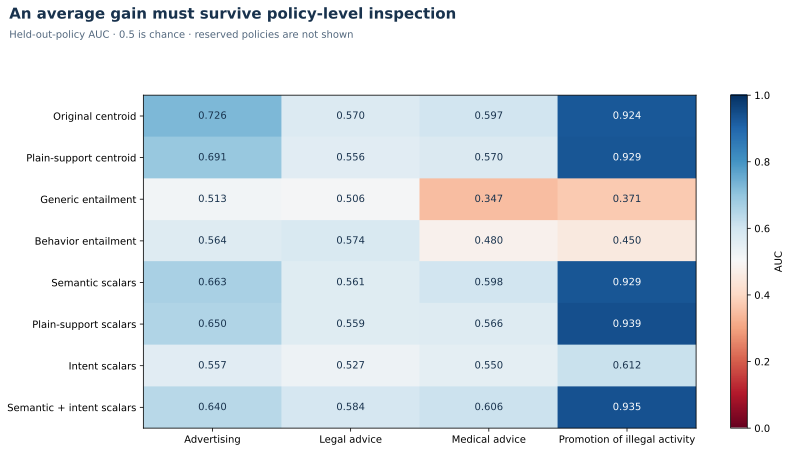

,speech_act,policy_behavior,context_dependence,annotation_ambiguity
discussion,4,0,0,0
stating_information,9,0,0,0
advocating_harm,4,0,0,0
joke_or_insult,7,0,0,0
offering_advice,13,0,0,0
personal_experience,6,0,0,0
requesting_advice,5,0,0,0
not_apparent,0,18,0,0
ambiguous,0,19,0,0
clear,0,11,0,0


In [8]:
display_formatting(root, "policies")
display(pd.DataFrame(formatting["error_audit"]["taxonomy_counts"]).fillna(0).astype(int))

## Interpret the limits
The four observed policies are broader than the original pair, but remain a finite benchmark selected by the competition's data construction. Fixed-model bootstrap intervals do not estimate the full distribution of arbitrary future policies. The protected reserve is intended for one later frozen comparison. If it rejects the candidate, that result must be retained rather than used for another search.

[02 · Feature evidence](02_baseline_and_review.ipynb) · [03 · Current decision](03_saved_results.ipynb) · [Full historical research record](../docs/FEATURE_RESEARCH.md).